# L=32 XY — raw PCA on three-phase cyclic channels

Every XY spin is encoded using exactly the pre-normalization channels supplied to the original frozen ResNet analysis:

$$R=\frac{1+\cos\theta}{2},\quad G=\frac{1+\cos(\theta-2\pi/3)}{2},\quad B=\frac{1+\cos(\theta+2\pi/3)}{2}.$$

The three $32\times32$ channels are flattened into 3,072 raw PCA features. No resizing or ImageNet normalization is used for raw PCA. This isolates the effect of the pretrained ResNet transformation while holding its physical input encoding fixed.

In [1]:
from pathlib import Path
import json
import colorsys

import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score
from sklearn.neighbors import KNeighborsClassifier

L = 32
N_SITES = L * L
N_RUNS = 10_000
N_T = 41
BINS = 10
N_CONFIGS = N_RUNS * N_T * BINS
TBKT = 0.89294
RATIOS = np.array([
    .60,.70,.78,.84,.87,.89,.90,.91,.92,.93,.94,.95,.96,.97,.98,.99,
    1.00,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.10,1.11,
    1.12,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.30,1.45,1.60,1.80,
], dtype=np.float64)
TEMPERATURES = RATIOS * TBKT
DATA_ROOT = Path('/home/lledson/senior-thesis/data/raw/xy32_broad')
OUTPUT_ROOT = Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

run_dirs = sorted(DATA_ROOT.glob('xy32_broad_[0-9]*'), key=lambda p: int(p.name.rsplit('_', 1)[1]))
assert len(run_dirs) == N_RUNS, len(run_dirs)
temperature_ids = np.tile(np.repeat(np.arange(N_T, dtype=np.int8), BINS), N_RUNS)
configuration_temperatures = TEMPERATURES[temperature_ids]
fit_bins = (np.arange(N_RUNS)[:, None] + np.arange(N_T)[None, :]) % BINS
FIT_INDICES = ((np.arange(N_RUNS)[:, None] * N_T + np.arange(N_T)[None, :]) * BINS + fit_bins).reshape(-1)

ANGLES_PATH = OUTPUT_ROOT / 'all_angles_float16.npy'
PROGRESS_PATH = OUTPUT_ROOT / 'angle_cache_progress.txt'
MAG_PATH = OUTPUT_ROOT / 'magnetization_magnitude.npy'

def build_angle_cache():
    if ANGLES_PATH.exists():
        angles = np.lib.format.open_memmap(ANGLES_PATH, mode='r+')
        assert angles.shape == (N_CONFIGS, L, L)
        start_run = int(PROGRESS_PATH.read_text()) if PROGRESS_PATH.exists() else N_RUNS
    else:
        angles = np.lib.format.open_memmap(ANGLES_PATH, mode='w+', dtype=np.float16, shape=(N_CONFIGS, L, L))
        start_run = 0
    for run_i in range(start_run, N_RUNS):
        run_dir = run_dirs[run_i]
        name = run_dir.name
        block = np.loadtxt(run_dir / f'spinConfigs_{name}.txt', dtype=np.float32).reshape(N_T * BINS, L, L)
        start = run_i * N_T * BINS
        angles[start:start + N_T * BINS] = block.astype(np.float16)
        if (run_i + 1) % 50 == 0 or run_i + 1 == N_RUNS:
            angles.flush(); PROGRESS_PATH.write_text(str(run_i + 1))
            if (run_i + 1) % 500 == 0: print(f'Cached {run_i + 1:,}/{N_RUNS:,} runs', flush=True)
    del angles
    return np.load(ANGLES_PATH, mmap_mode='r')

def build_magnetization(angles, batch_size=8192):
    if MAG_PATH.exists(): return np.load(MAG_PATH, mmap_mode='r')
    out = np.lib.format.open_memmap(MAG_PATH, mode='w+', dtype=np.float32, shape=(N_CONFIGS,))
    for start in range(0, N_CONFIGS, batch_size):
        stop = min(start + batch_size, N_CONFIGS)
        a = np.asarray(angles[start:stop], dtype=np.float32)
        mx = np.cos(a).mean((1,2)); my = np.sin(a).mean((1,2))
        out[start:stop] = np.sqrt(mx*mx + my*my)
    out.flush(); del out
    return np.load(MAG_PATH, mmap_mode='r')

def magnetization_plot(mag, prefix):
    shaped = np.asarray(mag).reshape(N_RUNS, N_T, BINS)
    seed_means = shaped.mean(2)
    mean = seed_means.mean(0); sem = seed_means.std(0, ddof=1) / np.sqrt(N_RUNS)
    table = pd.DataFrame({'T_over_TBKT': RATIOS, 'temperature': TEMPERATURES, 'mean_magnitude': mean, 'seed_sem': sem})
    table.to_csv(OUTPUT_ROOT / f'{prefix}_magnetization.csv', index=False)
    fig, ax = plt.subplots(figsize=(9,5.5))
    ax.errorbar(RATIOS, mean, yerr=sem, fmt='o-', ms=3.5, capsize=2)
    ax.axvline(1, color='black', ls='--', lw=1, label=r'$T_{BKT}$')
    ax.axvspan(.90, 1.20, color='tab:orange', alpha=.08, label='dense grid')
    ax.set(xlabel=r'$T/T_{BKT}$', ylabel=r'$\langle |m|\rangle$', title=r'$32\times32$ XY magnetization calculated directly from spins', ylim=(0,1))
    ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
    fig.savefig(OUTPUT_ROOT / f'{prefix}_magnetization.png', dpi=220); plt.show(); plt.close(fig)
    return table

def cyclic_rgb(angle):
    hue = np.mod(angle, 2*np.pi)/(2*np.pi)
    return hsv_to_rgb(np.stack([hue, np.ones_like(hue), np.ones_like(hue)], axis=-1))

def cossin_rgb(angle):
    return np.stack([.5+.5*np.cos(angle), .5+.5*np.sin(angle), np.full_like(angle,.406)], axis=-1)

def threephase_rgb(angle):
    phases=np.array([0,-2*np.pi/3,2*np.pi/3],dtype=np.float32)
    return .5+.5*np.cos(angle[...,None]+phases)

def vector_rgb(x, y):
    hue = np.mod(np.arctan2(y, x), 2*np.pi)/(2*np.pi)
    magnitude = np.sqrt(x*x+y*y)
    scale = max(float(np.percentile(magnitude, 99)), 1e-6)
    sat = np.clip(magnitude/scale, 0, 1)
    return hsv_to_rgb(np.stack([hue, sat, np.ones_like(hue)], axis=-1))

def spin_examples(angles, encoding='cyclic'):
    render={'cyclic':cyclic_rgb,'cossin':cossin_rgb,'threephase':threephase_rgb}[encoding]
    fig, axes = plt.subplots(3, 5, figsize=(12,7), constrained_layout=True)
    for row, ti in enumerate([0, 16, 40]):
        for col in range(5):
            idx = (col * N_T + ti) * BINS
            axes[row,col].imshow(render(np.asarray(angles[idx], dtype=np.float32)), interpolation='nearest')
            axes[row,col].set_title(fr'$T/T_{{BKT}}={RATIOS[ti]:.2f}$')
            axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
    labels={'cyclic':'cyclic hue wheel','cossin':r'$R=(\cos\theta+1)/2$, $G=(\sin\theta+1)/2$, neutral $B$','threephase':r'three cosine channels separated by $120^\circ$'}
    label=labels[encoding]
    fig.suptitle(f'XY configurations rendered as {label}')
    fig.savefig(OUTPUT_ROOT/f'xy32_{encoding}_spin_examples.png', dpi=200); plt.show(); plt.close(fig)

def raw_features(angles, indices):
    block = np.asarray(angles[indices], dtype=np.float32)
    a = block.reshape(block.shape[0], N_SITES)
    return np.concatenate([np.cos(a), np.sin(a)], axis=1).astype(np.float32, copy=False)

def raw_threephase_features(angles,indices):
    block=np.asarray(angles[indices],dtype=np.float32)
    phases=np.array([0,-2*np.pi/3,2*np.pi/3],dtype=np.float32).reshape(1,3,1,1)
    image=.5+.5*np.cos(block[:,None,:,:]+phases)
    return image.reshape(block.shape[0],3*N_SITES).astype(np.float32,copy=False)

def build_resnet_embeddings(angles, encoding='cyclic'):
    from torchvision.models import ResNet18_Weights, resnet18
    if encoding not in ('cyclic','cossin'): raise ValueError(encoding)
    path = OUTPUT_ROOT/f'resnet18_{encoding}_embeddings_float16.npy'
    progress = OUTPUT_ROOT/f'resnet18_{encoding}_embedding_progress.txt'
    if path.exists():
        out = np.lib.format.open_memmap(path, mode='r+'); start = int(progress.read_text()) if progress.exists() else N_CONFIGS
    else:
        out = np.lib.format.open_memmap(path, mode='w+', dtype=np.float16, shape=(N_CONFIGS,512)); start=0
    if start < N_CONFIGS:
        weights=ResNet18_Weights.DEFAULT; model=resnet18(weights=weights); model.fc=torch.nn.Identity(); model.eval().to(DEVICE)
        mean=torch.tensor(weights.transforms().mean, device=DEVICE).view(1,3,1,1)
        std=torch.tensor(weights.transforms().std, device=DEVICE).view(1,3,1,1)
        phases=torch.tensor([0, -2*np.pi/3, 2*np.pi/3], device=DEVICE).view(1,3,1,1)
        batch_size=512
        with torch.inference_mode():
            for begin in range(start, N_CONFIGS, batch_size):
                end=min(begin+batch_size,N_CONFIGS)
                a=torch.tensor(np.asarray(angles[begin:end], dtype=np.float32), device=DEVICE).unsqueeze(1)
                if encoding=='cyclic':
                    image=.5+.5*torch.cos(a+phases)
                else:
                    cos_channel=.5+.5*torch.cos(a); sin_channel=.5+.5*torch.sin(a)
                    blue_channel=torch.full_like(cos_channel,float(mean[0,2,0,0]))
                    image=torch.cat([cos_channel,sin_channel,blue_channel],dim=1)
                image=F.interpolate(image, size=(224,224), mode='nearest')
                image=(image-mean)/std
                with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=DEVICE.type=='cuda'):
                    emb=model(image)
                out[begin:end]=emb.float().cpu().numpy().astype(np.float16)
                if end % 50_000 < batch_size or end==N_CONFIGS:
                    out.flush(); progress.write_text(str(end)); print(f'Embedded {end:,}/{N_CONFIGS:,}', flush=True)
        del model
    out.flush(); del out
    return np.load(path, mmap_mode='r')

def fit_pca(fetch, dimension, prefix, batch_size):
    path=OUTPUT_ROOT/f'{prefix}_pca.npz'
    if path.exists():
        saved=np.load(path); return saved['mean'],saved['eigenvalues'],saved['components']
    total=torch.zeros(dimension,dtype=torch.float64,device=DEVICE)
    second=torch.zeros((dimension,dimension),dtype=torch.float64,device=DEVICE)
    for start in range(0,len(FIT_INDICES),batch_size):
        idx=FIT_INDICES[start:start+batch_size]
        x=torch.tensor(fetch(idx),device=DEVICE,dtype=torch.float64)
        total+=x.sum(0); second+=x.T@x
    mean_t=total/len(FIT_INDICES)
    cov=(second-len(FIT_INDICES)*torch.outer(mean_t,mean_t))/(len(FIT_INDICES)-1)
    vals,vecs=torch.linalg.eigh(cov); order=torch.argsort(vals,descending=True)
    mean=mean_t.cpu().numpy(); eigenvalues=vals[order].cpu().numpy(); components=vecs[:,order].T.cpu().numpy()
    np.savez(path,mean=mean,eigenvalues=eigenvalues,components=components)
    return mean,eigenvalues,components

def score_pcs(fetch, mean, components, prefix, batch_size, n_scores=40):
    path=OUTPUT_ROOT/f'{prefix}_pc1-{n_scores}_scores.npy'
    if path.exists(): return np.load(path,mmap_mode='r')
    out=np.lib.format.open_memmap(path,mode='w+',dtype=np.float32,shape=(N_CONFIGS,n_scores))
    comp=torch.tensor(components[:n_scores],device=DEVICE,dtype=torch.float32)
    mu=torch.tensor(mean,device=DEVICE,dtype=torch.float32)
    for start in range(0,N_CONFIGS,batch_size):
        stop=min(start+batch_size,N_CONFIGS); idx=slice(start,stop)
        x=torch.tensor(fetch(idx),device=DEVICE,dtype=torch.float32)
        out[start:stop]=((x-mu)@comp.T).cpu().numpy()
        if stop%100_000<batch_size: print(f'Scored {stop:,}/{N_CONFIGS:,}',flush=True)
    out.flush(); del out
    return np.load(path,mmap_mode='r')

def variance_and_overview(eigenvalues,scores,prefix,title):
    evr=eigenvalues/eigenvalues.sum(); cumulative=np.cumsum(evr); n90=int(np.searchsorted(cumulative,.9)+1)
    shown=min(max(n90,12),100); x=np.arange(1,shown+1)
    fig,ax=plt.subplots(figsize=(12,5)); ax.bar(x,evr[:shown],alpha=.8,label='Individual variance'); ax.set(xlabel='Principal component',ylabel='Explained variance ratio',title=f'{title}: {n90} PCs retain 90% variance'); ax.grid(axis='y',alpha=.25)
    other=ax.twinx(); other.plot(x,cumulative[:shown],'o-',ms=2,color='tab:red',label='Cumulative variance'); other.axhline(.9,color='black',ls='--'); other.set(ylabel='Cumulative explained variance',ylim=(0,1.02)); h,l=ax.get_legend_handles_labels(); h2,l2=other.get_legend_handles_labels(); ax.legend(h+h2,l+l2)
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT/f'{prefix}_explained_variance.png',dpi=220); plt.show(); plt.close(fig)
    rng=np.random.default_rng(2026); sample=[]
    for ti in range(N_T):
        candidates=((np.arange(N_RUNS)*N_T+ti)*BINS)[:,None]+np.arange(BINS)
        sample.append(rng.choice(candidates.ravel(),1000,replace=False))
    sample=np.concatenate(sample)
    shaped=np.asarray(scores[:,:6]).reshape(N_RUNS,N_T,BINS,6); means=shaped.mean((0,2)); sem=shaped.std((0,2),ddof=1)/np.sqrt(N_RUNS*BINS)
    fig,axes=plt.subplots(1,2,figsize=(15,5.5)); sc=axes[0].scatter(scores[sample,0],scores[sample,1],c=RATIOS[temperature_ids[sample]],s=2,alpha=.3,cmap='turbo',rasterized=True); fig.colorbar(sc,ax=axes[0],label=r'$T/T_{BKT}$'); axes[0].set(xlabel='PC1 score',ylabel='PC2 score',title=f'{title}: first two PCs')
    for pc in range(6): axes[1].errorbar(RATIOS,means[:,pc],yerr=sem[:,pc],marker='o',ms=2,lw=1,label=f'PC{pc+1}')
    axes[1].axvline(1,color='black',ls='--',lw=1); axes[1].set(xlabel=r'$T/T_{BKT}$',ylabel='Mean PC score',title='First six PCs versus temperature'); axes[1].grid(alpha=.25); axes[1].legend(ncol=2,fontsize=8)
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT/f'{prefix}_pca_overview.png',dpi=220); plt.show(); plt.close(fig)
    return evr,cumulative,n90

def vector_tail_average(angles,indices,centered,batch=4096):
    sx=np.zeros((L,L),np.float64); sy=np.zeros((L,L),np.float64); count=0
    for start in range(0,len(indices),batch):
        a=np.asarray(angles[indices[start:start+batch]],dtype=np.float32); x=np.cos(a); y=np.sin(a)
        if centered:
            x-=x.mean((1,2),keepdims=True); y-=y.mean((1,2),keepdims=True)
        sx+=x.sum(0); sy+=y.sum(0); count+=len(a)
    return sx/count,sy/count

def tail_plots(angles,scores,mag,prefix,title):
    tail=max(1,int(.02*N_CONFIGS)); extrema=[]
    fig,axes=plt.subplots(5,2,figsize=(8,17),constrained_layout=True)
    rawfig,rawaxes=plt.subplots(5,3,figsize=(10,17),constrained_layout=True)
    cenfig,cenaxes=plt.subplots(5,3,figsize=(10,17),constrained_layout=True)
    for pc in range(5):
        values=np.asarray(scores[:,pc]); low=np.argpartition(values,tail)[:tail]; high=np.argpartition(values,len(values)-tail)[-tail:]
        for col,(label,idx) in enumerate((('Most negative score',int(np.argmin(values))),('Most positive score',int(np.argmax(values))))):
            axes[pc,col].imshow(cyclic_rgb(np.asarray(angles[idx],dtype=np.float32))); axes[pc,col].set_title(f'PC{pc+1}: {label}\nT/TBKT={RATIOS[temperature_ids[idx]]:.2f}, |m|={mag[idx]:.3f}, score={values[idx]:+.2f}'); axes[pc,col].set_xticks([]); axes[pc,col].set_yticks([]); extrema.append({'pc':pc+1,'direction':label,'index':idx,'T_over_TBKT':RATIOS[temperature_ids[idx]],'magnetization':float(mag[idx]),'score':float(values[idx])})
        for target_axes,centered in ((rawaxes,False),(cenaxes,True)):
            lx,ly=vector_tail_average(angles,low,centered); hx,hy=vector_tail_average(angles,high,centered)
            for col,(x,y) in enumerate(((lx,ly),(hx,hy),(hx-lx,hy-ly))):
                target_axes[pc,col].imshow(vector_rgb(x,y)); target_axes[pc,col].set_xticks([]); target_axes[pc,col].set_yticks([])
            target_axes[pc,0].set_ylabel(f'PC{pc+1} score tails')
    axes[0,0].set_title('Most negative score'); axes[0,1].set_title('Most positive score'); fig.suptitle(f'{title}: actual XY configurations at PC1–PC5 extrema'); fig.savefig(OUTPUT_ROOT/f'{prefix}_pc1-5_extreme_configurations.png',dpi=220); plt.show(); plt.close(fig)
    for a in (rawaxes,cenaxes): a[0,0].set_title('Bottom 2%: mean vector'); a[0,1].set_title('Top 2%: mean vector'); a[0,2].set_title('Top minus bottom')
    rawfig.suptitle(f'{title}: raw vector-field averages in PC1–PC5 score tails\nHue = direction, saturation = vector magnitude'); rawfig.savefig(OUTPUT_ROOT/f'{prefix}_pc1-5_raw_tail_vectors.png',dpi=220); plt.show(); plt.close(rawfig)
    cenfig.suptitle(f'{title}: PC-tail vector patterns after subtracting each configuration mean\nHue = residual direction, saturation = magnitude'); cenfig.savefig(OUTPUT_ROOT/f'{prefix}_pc1-5_mean_subtracted_tail_vectors.png',dpi=220); plt.show(); plt.close(cenfig)
    pd.DataFrame(extrema).to_csv(OUTPUT_ROOT/f'{prefix}_pc1-5_extrema.csv',index=False)

def pc40_clustering_features(block,prefix):
    block=np.asarray(block,dtype=np.float32)
    if prefix=='raw_spin':
        # PC1 and PC2 are the degenerate global-rotation pair. Their radius keeps
        # their information but removes the arbitrary angular cut through the ring.
        radius=np.sqrt(block[:,0]**2+block[:,1]**2)[:,None]
        return np.concatenate([radius,block[:,2:40]],axis=1)
    return block[:,:40]

def cluster_first_40_pcs(scores,prefix,title):
    rng=np.random.default_rng(42)
    fit_features=pc40_clustering_features(scores[FIT_INDICES,:40],prefix)
    if prefix.startswith('resnet18') or prefix=='raw_threephase':
        model=KMeans(2,random_state=42,n_init=10,max_iter=300,algorithm='lloyd').fit(fit_features)
        method='Exact sklearn KMeans (Lloyd) on first 40 PCs'
    else:
        model=MiniBatchKMeans(2,random_state=42,batch_size=8192,n_init=20,max_iter=300).fit(fit_features)
        method='MiniBatchKMeans on first 40 PCs'
    path=OUTPUT_ROOT/f'{prefix}_pc40_cluster_labels.npy'; labels=np.lib.format.open_memmap(path,mode='w+',dtype=np.int8,shape=(N_CONFIGS,))
    for start in range(0,N_CONFIGS,100_000):
        stop=min(start+100_000,N_CONFIGS); labels[start:stop]=model.predict(pc40_clustering_features(scores[start:stop,:40],prefix))
    labels.flush(); unordered=np.asarray(labels)
    mean_ratios=[RATIOS[temperature_ids[unordered==k]].mean() for k in range(2)]; order=np.argsort(mean_ratios); mapping=np.empty(2,dtype=np.int8); mapping[order[0]]=0; mapping[order[1]]=1; labels[:]=mapping[unordered]; labels.flush(); aligned=np.asarray(labels)
    pop=np.stack([(aligned.reshape(N_RUNS,N_T,BINS)==k).mean((0,2)) for k in range(2)])
    rows=[]
    for ti,r in enumerate(RATIOS):
        for k,name in enumerate(('Low-temperature cluster','High-temperature cluster')): rows.append({'T_over_TBKT':r,'cluster':k,'label':name,'fraction':pop[k,ti]})
    pd.DataFrame(rows).to_csv(OUTPUT_ROOT/f'{prefix}_cluster_populations.csv',index=False)
    eval_idx=[]
    for ti in range(N_T):
        candidates=((np.arange(N_RUNS)*N_T+ti)*BINS)[:,None]+np.arange(BINS); eval_idx.append(rng.choice(candidates.ravel(),125,replace=False))
    eval_idx=np.concatenate(eval_idx); eval_features=pc40_clustering_features(scores[eval_idx,:40],prefix); sil=float(silhouette_score(eval_features,aligned[eval_idx]))
    feature_label='PC1–PC2 radius + PCs 3–40' if prefix=='raw_spin' else 'PCs 1–40'
    fig,ax=plt.subplots(figsize=(9,5.5)); ax.plot(RATIOS,pop[0],'o-',ms=3,label='Low-temperature cluster'); ax.plot(RATIOS,pop[1],'o-',ms=3,label='High-temperature cluster'); ax.axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$'); ax.set(xlabel=r'$T/T_{BKT}$',ylabel='Cluster fraction',title=f'{title}: 40-PC clustering\nFeatures: {feature_label}',ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(OUTPUT_ROOT/f'{prefix}_cluster_populations.png',dpi=220); plt.show(); plt.close(fig)
    diagnostics={'method':method,'clustering_pcs':40,'clustering_features':feature_label,'fit_observations':len(FIT_INDICES),'silhouette':sil,'evaluation_size':len(eval_idx),'low_endpoint_high_cluster_fraction':float(pop[1,0]),'high_endpoint_high_cluster_fraction':float(pop[1,-1])}
    (OUTPUT_ROOT/f'{prefix}_cluster_diagnostics.json').write_text(json.dumps(diagnostics,indent=2)); return labels,diagnostics

def cluster_resnet_pc2(scores,title):
    """Targeted diagnostic: cluster the visually temperature-ordered ResNet PC2 alone."""
    rng=np.random.default_rng(42)
    model=MiniBatchKMeans(2,random_state=42,batch_size=8192,n_init=20,max_iter=300).fit(np.asarray(scores[FIT_INDICES,1:2],dtype=np.float32))
    path=OUTPUT_ROOT/'resnet18_pc2_cluster_labels.npy'; labels=np.lib.format.open_memmap(path,mode='w+',dtype=np.int8,shape=(N_CONFIGS,))
    for start in range(0,N_CONFIGS,100_000):
        stop=min(start+100_000,N_CONFIGS); labels[start:stop]=model.predict(np.asarray(scores[start:stop,1:2],dtype=np.float32))
    labels.flush(); unordered=np.asarray(labels)
    mean_ratios=[RATIOS[temperature_ids[unordered==k]].mean() for k in range(2)]; order=np.argsort(mean_ratios); mapping=np.empty(2,dtype=np.int8); mapping[order[0]]=0; mapping[order[1]]=1; labels[:]=mapping[unordered]; labels.flush(); aligned=np.asarray(labels)
    pop=np.stack([(aligned.reshape(N_RUNS,N_T,BINS)==k).mean((0,2)) for k in range(2)])
    rows=[]
    for ti,r in enumerate(RATIOS):
        for k,name in enumerate(('Low-temperature cluster','High-temperature cluster')): rows.append({'T_over_TBKT':r,'cluster':k,'label':name,'fraction':pop[k,ti]})
    pd.DataFrame(rows).to_csv(OUTPUT_ROOT/'resnet18_pc2_cluster_populations.csv',index=False)
    eval_idx=[]
    for ti in range(N_T):
        candidates=((np.arange(N_RUNS)*N_T+ti)*BINS)[:,None]+np.arange(BINS); eval_idx.append(rng.choice(candidates.ravel(),125,replace=False))
    eval_idx=np.concatenate(eval_idx); sil=float(silhouette_score(np.asarray(scores[eval_idx,1:2],dtype=np.float32),aligned[eval_idx]))
    fig,ax=plt.subplots(figsize=(9,5.5)); ax.plot(RATIOS,pop[0],'o-',ms=3,label='Low-temperature cluster'); ax.plot(RATIOS,pop[1],'o-',ms=3,label='High-temperature cluster'); ax.axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$'); ax.set(xlabel=r'$T/T_{BKT}$',ylabel='Cluster fraction',title=f'{title}: K-means on ResNet PC2 only\nTargeted diagnostic selected after inspecting the PC temperature trends',ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'resnet18_pc2_cluster_populations.png',dpi=220); plt.show(); plt.close(fig)
    diagnostics={'method':'MiniBatchKMeans on ResNet PC2 only','clustering_pcs':1,'clustering_features':'ResNet PC2','selection_note':'PC2 was selected after inspecting its temperature trend; this is a targeted diagnostic, not the representation-blind 40-PC benchmark.','fit_observations':len(FIT_INDICES),'silhouette':sil,'evaluation_size':len(eval_idx),'low_endpoint_high_cluster_fraction':float(pop[1,0]),'high_endpoint_high_cluster_fraction':float(pop[1,-1])}
    (OUTPUT_ROOT/'resnet18_pc2_cluster_diagnostics.json').write_text(json.dumps(diagnostics,indent=2)); return labels,diagnostics

def run_representation(kind):
    angles=build_angle_cache(); mag=build_magnetization(angles); magnetization_plot(mag,kind)
    if kind=='resnet18':
        spin_examples(angles,'cyclic'); features=build_resnet_embeddings(angles,'cyclic'); fetch=lambda idx: np.asarray(features[idx],dtype=np.float32); dim=512; batch=8192; title='Frozen ImageNet ResNet-18 on cyclic RGB spins'
    elif kind=='resnet18_cossin':
        spin_examples(angles,'cossin'); features=build_resnet_embeddings(angles,'cossin'); fetch=lambda idx: np.asarray(features[idx],dtype=np.float32); dim=512; batch=8192; title=r'Frozen ImageNet ResNet-18 on matched $(\cos\theta,\sin\theta)$ channels'
    elif kind=='raw_threephase':
        spin_examples(angles,'threephase'); fetch=lambda idx: raw_threephase_features(angles,idx); dim=3*N_SITES; batch=1024; title='Raw PCA on the three-phase cyclic RGB spin field'
    elif kind=='raw_spin':
        fetch=lambda idx: raw_features(angles,idx); dim=2*N_SITES; batch=2048; title=r'Raw $(\cos\theta,\sin\theta)$ spin field'
    else: raise ValueError(kind)
    mean,eigenvalues,components=fit_pca(fetch,dim,kind,batch); scores=score_pcs(fetch,mean,components,kind,batch,n_scores=40); evr,cum,n90=variance_and_overview(eigenvalues,scores,kind,title); tail_plots(angles,scores,mag,kind,title); labels,diag=cluster_first_40_pcs(scores,kind,title)
    summary={'representation':kind,'observations':N_CONFIGS,'fit_observations':len(FIT_INDICES),'n90':n90,'clustering_pcs':40,'clustering_features':diag['clustering_features'],'first_six_evr':evr[:6].tolist(),'pc40_silhouette':diag['silhouette']}
    if kind=='resnet18':
        _,pc2_diag=cluster_resnet_pc2(scores,title); summary['pc2_kmeans_silhouette']=pc2_diag['silhouette']; summary['pc2_low_endpoint_high_cluster_fraction']=pc2_diag['low_endpoint_high_cluster_fraction']; summary['pc2_high_endpoint_high_cluster_fraction']=pc2_diag['high_endpoint_high_cluster_fraction']
    (OUTPUT_ROOT/f'{kind}_summary.json').write_text(json.dumps(summary,indent=2)); print(json.dumps(summary,indent=2)); return summary


## Complete raw three-phase analysis

The same 4.1 million observations and balanced 410,000-observation PCA fit set are used. The notebook reproduces magnetization, explained variance, PC temperature trends, PC1–PC5 extrema and tail maps, and exact K-means on PCs 1–40.

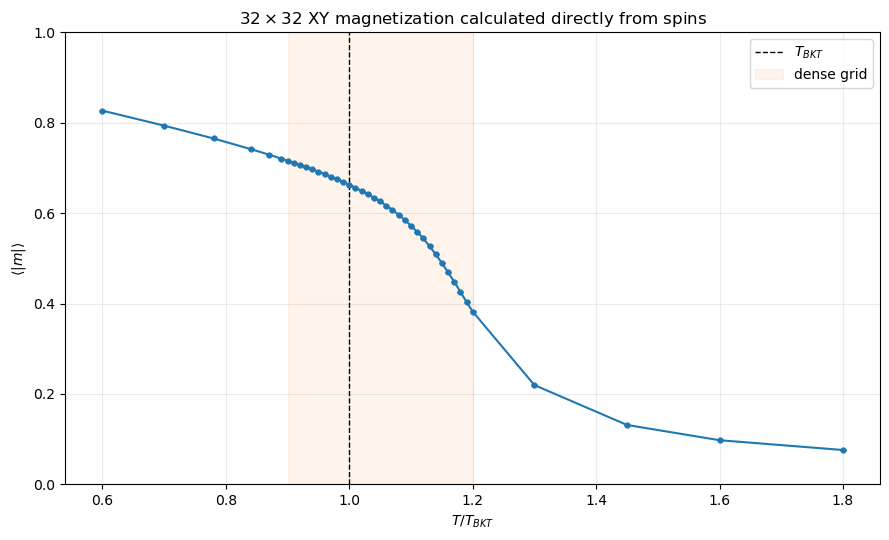

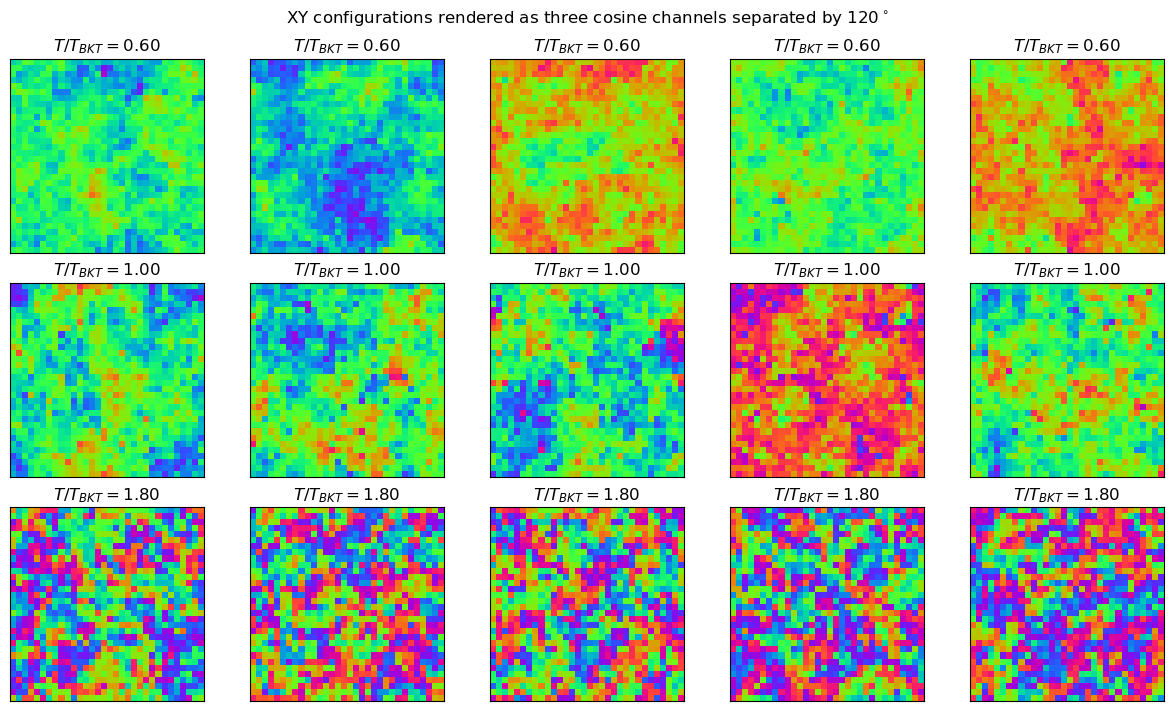

Scored 100,352/4,100,000


Scored 200,704/4,100,000


Scored 300,032/4,100,000


Scored 400,384/4,100,000


Scored 500,736/4,100,000


...

Scored 3,700,736/4,100,000


Scored 3,800,064/4,100,000


Scored 3,900,416/4,100,000


Scored 4,000,768/4,100,000


Scored 4,100,000/4,100,000


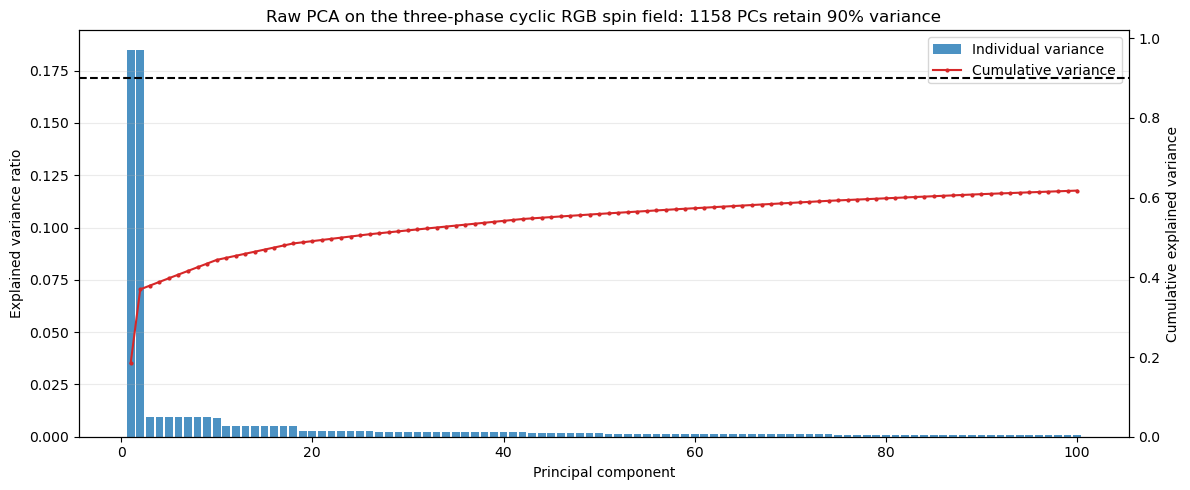

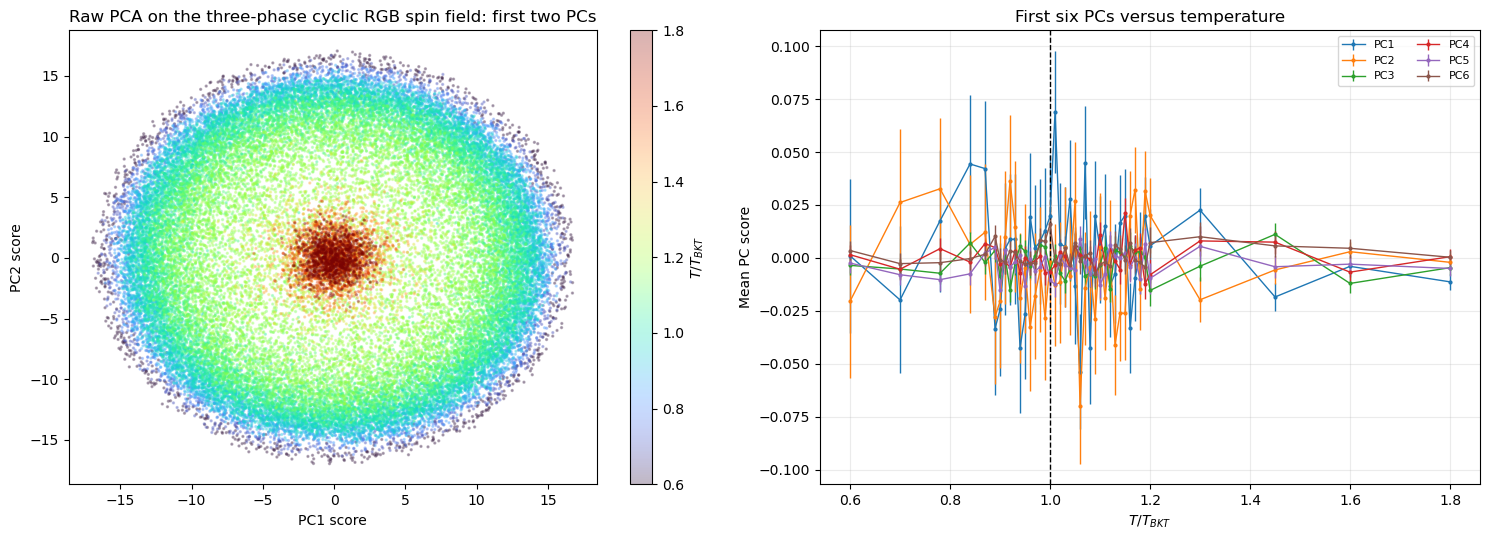

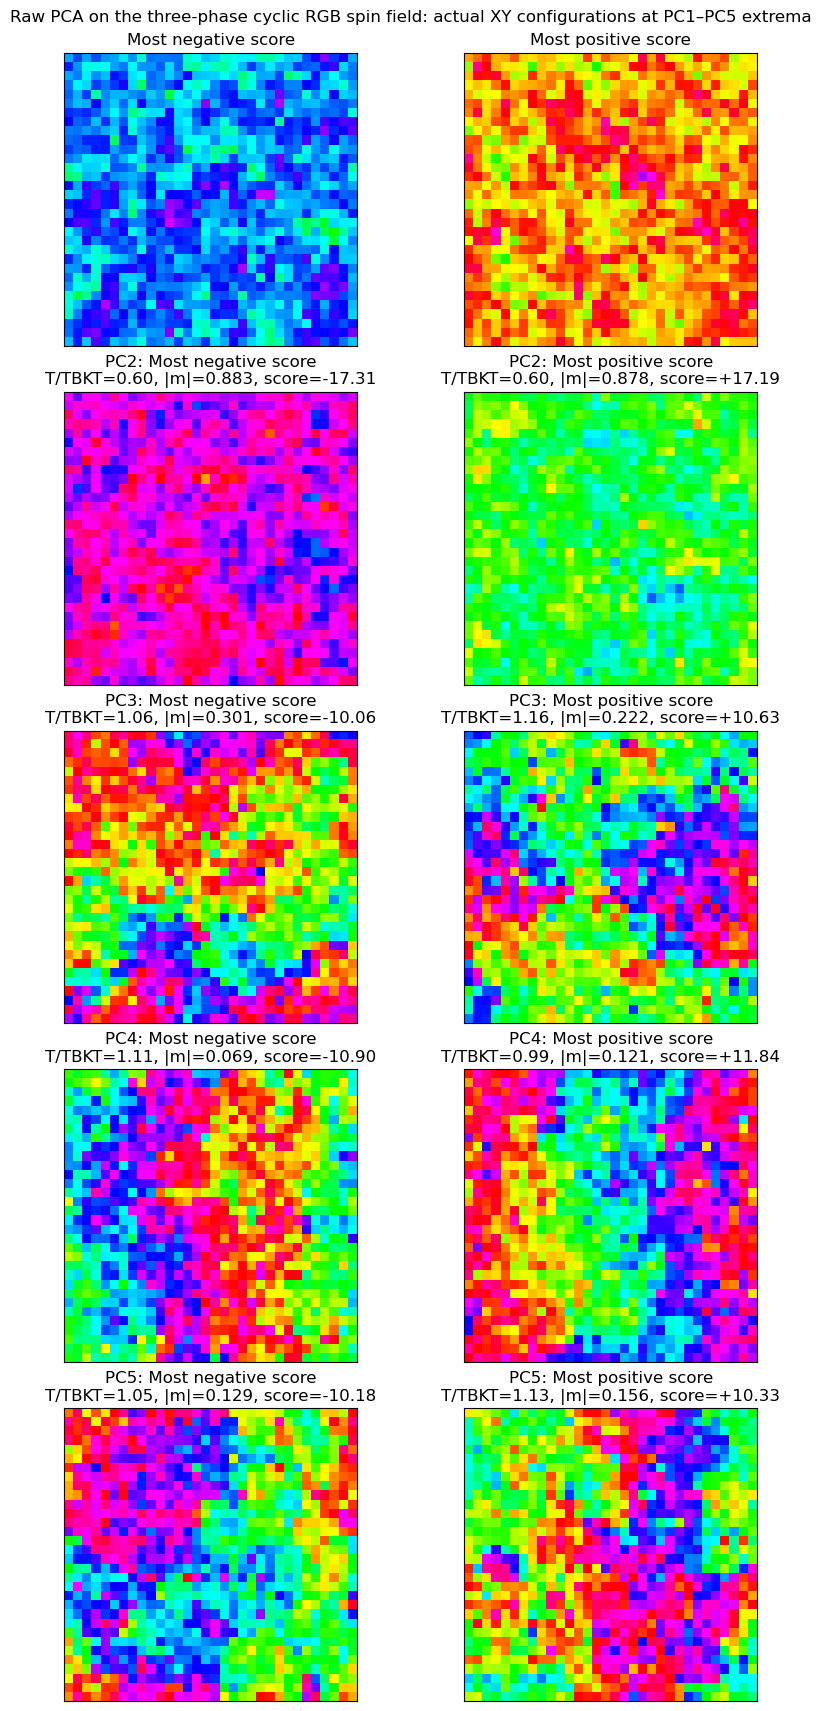

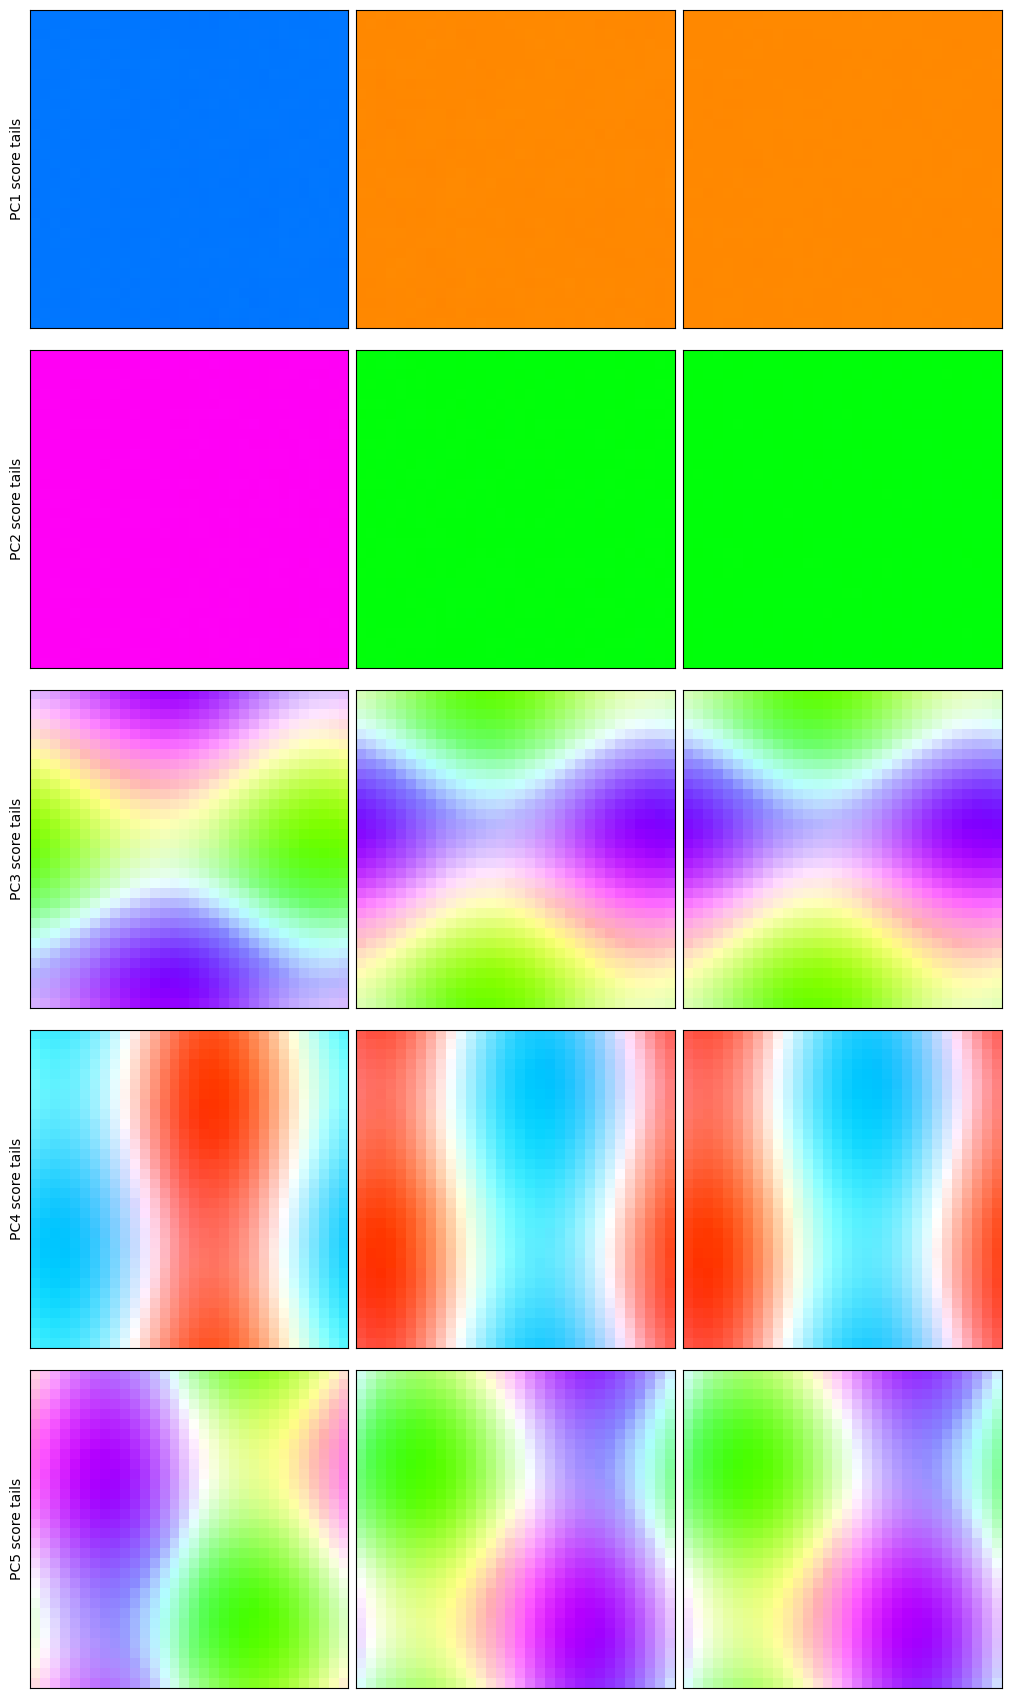

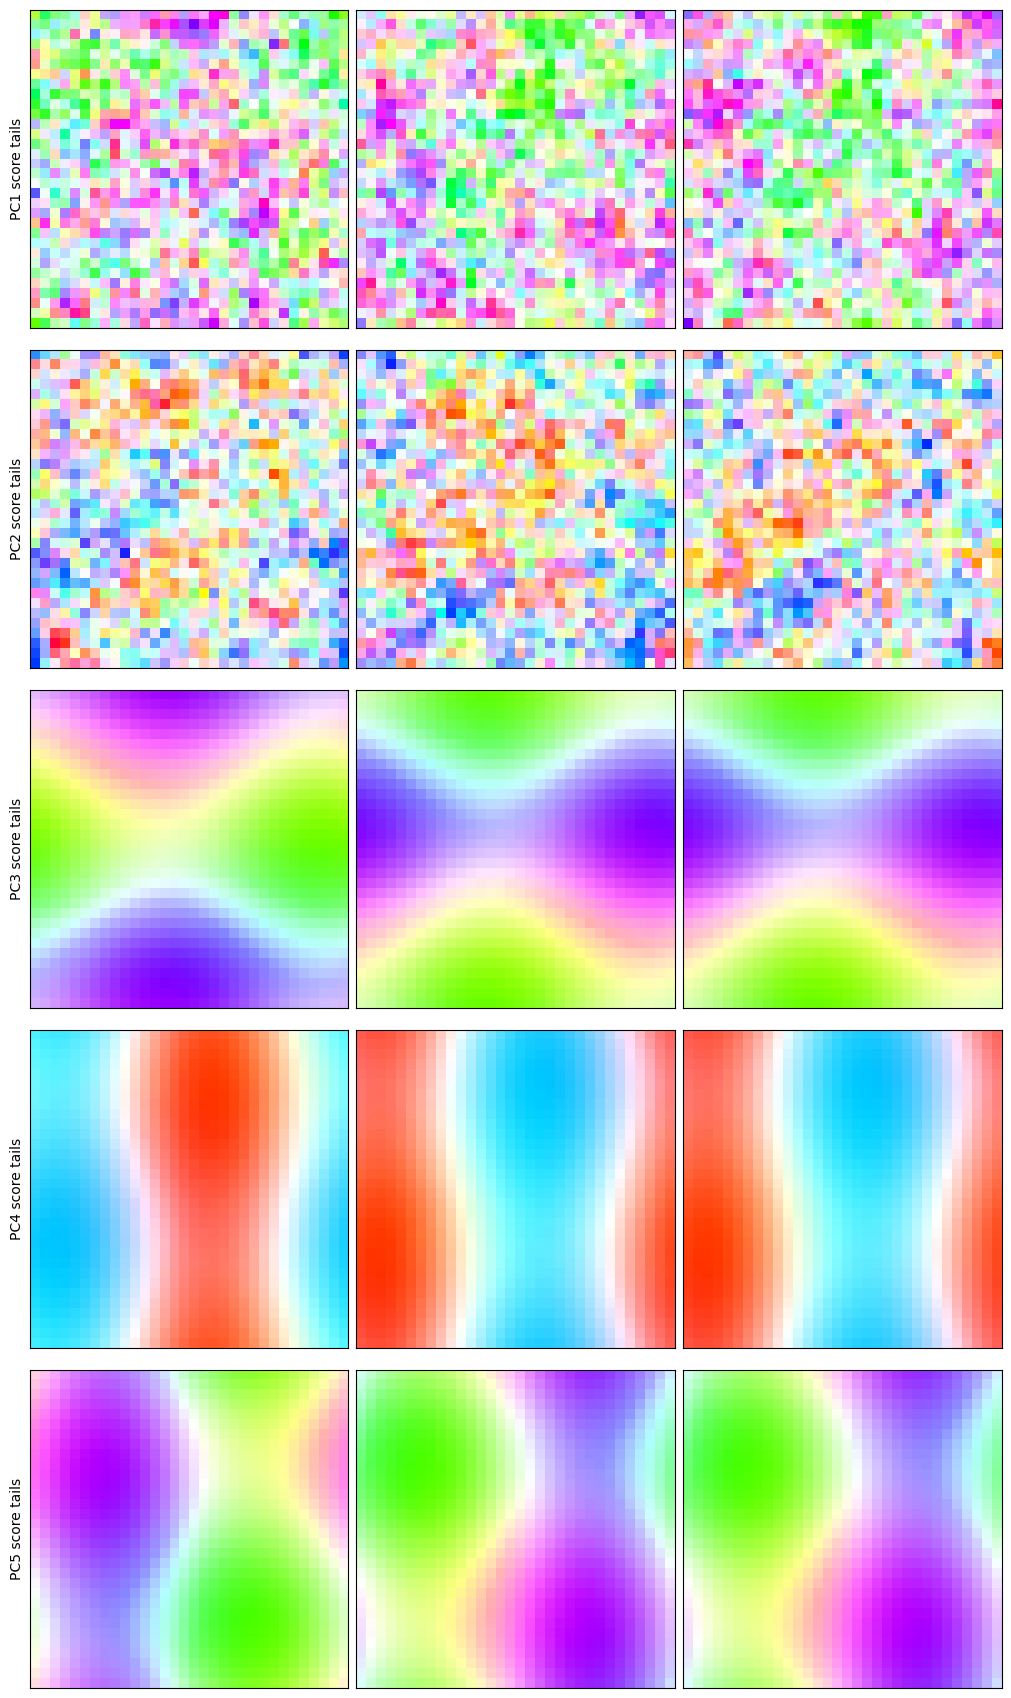

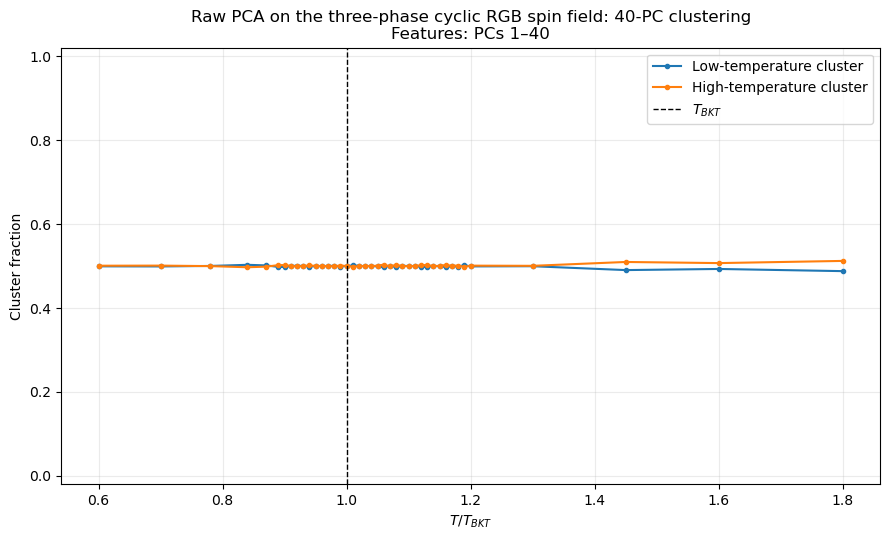

{
  "representation": "raw_threephase",
  "observations": 4100000,
  "fit_observations": 410000,
  "n90": 1158,
  "clustering_pcs": 40,
  "clustering_features": "PCs 1\u201340",
  "first_six_evr": [
    0.18499736492119798,
    0.18490298287121829,
    0.009329064317517568,
    0.009293589331456636,
    0.009249850208246743,
    0.009242329059955015
  ],
  "pc40_silhouette": 0.22367845475673676
}


{'representation': 'raw_threephase',
 'observations': 4100000,
 'fit_observations': 410000,
 'n90': 1158,
 'clustering_pcs': 40,
 'clustering_features': 'PCs 1–40',
 'first_six_evr': [0.18499736492119798,
  0.18490298287121829,
  0.009329064317517568,
  0.009293589331456636,
  0.009249850208246743,
  0.009242329059955015],
 'pc40_silhouette': 0.22367845475673676}

In [2]:
summary = run_representation('raw_threephase')
summary

## Interpretation guardrail

The three-phase encoding is an affine redundant representation of the two physical spin components. Raw-PCA results should therefore be equivalent to cos/sin PCA up to scale and rotations within degenerate PC subspaces. Any additional performance in frozen ResNet comes from its pretrained nonlinear spatial transformation and ImageNet preprocessing, not additional physical input information.